# Training Graph Auto Encoder

Training on 382 windows; testing on 500 windows.
Using device: cpu
GAE model params: 59,137
Epoch 01 | Loss: 0.6931 | Test AUC: 0.4292 | LR: 1.00e-04
Epoch 02 | Loss: 0.6917 | Test AUC: 0.4504 | LR: 1.00e-04
Epoch 03 | Loss: 0.6859 | Test AUC: 0.5795 | LR: 1.00e-04
Epoch 04 | Loss: 0.6663 | Test AUC: 0.6209 | LR: 1.00e-04


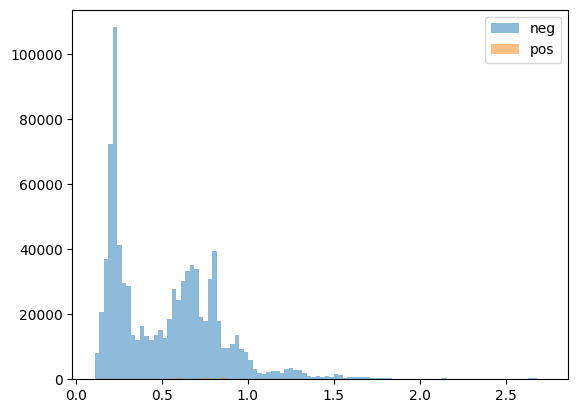

[Epoch 5] Best F1=0.0585 at threshold=1.3460
[Epoch 5] Youden’s J=0.5193 at thr=0.5828
Epoch 05 | Loss: 0.6299 | Test AUC: 0.7868 | LR: 1.00e-04
Epoch 06 | Loss: 0.6031 | Test AUC: 0.8286 | LR: 1.00e-04
Epoch 07 | Loss: 0.5871 | Test AUC: 0.8033 | LR: 1.00e-04
Epoch 08 | Loss: 0.5727 | Test AUC: 0.7726 | LR: 1.00e-04
Epoch 09 | Loss: 0.5635 | Test AUC: 0.7477 | LR: 1.00e-04


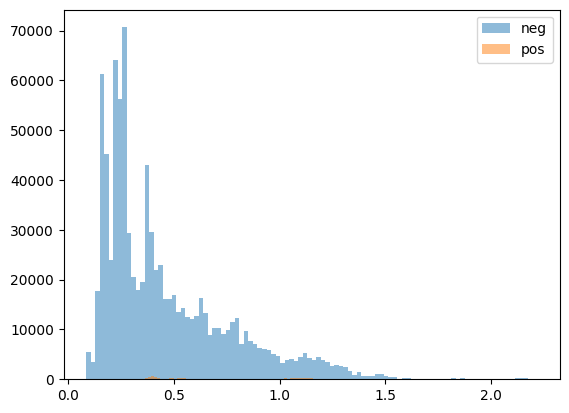

[Epoch 10] Best F1=0.0800 at threshold=1.0088
[Epoch 10] Youden’s J=0.4913 at thr=0.3686
Epoch 10 | Loss: 0.5551 | Test AUC: 0.7776 | LR: 1.00e-04

Total training time: 1049.36s, Avg per epoch: 104.94s

Loading best model for final evaluation...
Final Youden’s J=0.5703 at threshold=0.6062

FINAL SEMI-SUPERVISED GAE RESULTS
  Test AUC: 0.8286
  Total Positive: 7876
  Correct Positive: 7040
  Incorrect Positive: 836
  Total Negative: 897124
  Correct Negative: 606783
  Incorrect Negative: 290341


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn import MessagePassing
from torch_geometric.data import Batch
from torch_geometric.utils import negative_sampling, dropout_adj
from sklearn.metrics import roc_auc_score, average_precision_score
from torch_scatter import scatter_max
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# --- Super Efficient Batch-Optimized Sensor Attention K-Hop Aggregation ---
class BatchOptimizedSensorAttentionConv(MessagePassing):
    def __init__(self, in_channels, out_channels, max_hops=3, value_tolerance=0.01, heads=1, dropout=0.2):
        super().__init__(aggr='add')
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.max_hops = min(max_hops, 3)
        self.value_tolerance = value_tolerance
        self.heads = heads
        self.dropout = dropout
        self.node_proj = nn.Linear(in_channels, out_channels * heads, bias=False)
        self.neighbor_proj = nn.Linear(in_channels, out_channels * heads, bias=False)
        self.out_proj = nn.Linear(out_channels * heads, out_channels, bias=False)
        self.dropout_layer = nn.Dropout(dropout)

    def get_k_hop_edges_batched(self, edge_index, num_nodes, k, batch_size=None):
        if k == 1:
            return edge_index
        device = edge_index.device
        current_edges = edge_index
        for hop in range(k - 1):
            adj_dict = {}
            for i in range(current_edges.shape[1]):
                src, dst = current_edges[:, i]
                src, dst = src.item(), dst.item()
                adj_dict.setdefault(src, []).append(dst)
            new_edges = set()
            for src in adj_dict:
                for inter in adj_dict[src]:
                    if inter in adj_dict:
                        for dst in adj_dict[inter]:
                            if dst != src:
                                new_edges.add((src, dst))
            if not new_edges:
                break
            new_list = list(new_edges)
            if len(new_list) > edge_index.shape[1] * (k + 1):
                idx = torch.randperm(len(new_list))[:edge_index.shape[1] * (k + 1)]
                new_list = [new_list[i] for i in idx]
            current_edges = torch.tensor(new_list, device=device).t().contiguous()
        return current_edges

    def super_efficient_batch_aggregation(self, x, edge_index, batch=None):
        device = x.device
        num_nodes = x.size(0)
        if batch is not None:
            return self.handle_batched_graphs(x, edge_index, batch)
        output = torch.zeros(num_nodes, self.out_channels * self.heads, device=device)
        for hop in range(1, self.max_hops + 1):
            hop_edges = edge_index if hop == 1 else self.get_k_hop_edges_batched(edge_index, num_nodes, hop)
            if hop_edges.shape[1] == 0:
                continue
            row, col = hop_edges
            node_feats = self.node_proj(x)
            neigh_feats = self.neighbor_proj(x)
            diffs = torch.norm(x[col] - x[row], dim=1)
            max_idx = scatter_max(diffs, row, dim=0, dim_size=num_nodes)[1]
            valid = max_idx != -1
            if valid.sum() > 0:
                valid_nodes = torch.where(valid)[0]
                mask = torch.zeros(hop_edges.shape[1], dtype=torch.bool, device=device)
                for idx in valid_nodes:
                    edges = torch.where(row == idx)[0]
                    if edges.numel() > 0:
                        e = edges[torch.argmax(diffs[edges])]
                        mask[e] = True
                sel = torch.where(mask)[0]
                r, c = row[sel], col[sel]
                combined = 0.6 * node_feats[r] + 0.4 * neigh_feats[c]
                output[r] = combined
        no_nbors = (output.sum(dim=1) == 0)
        if no_nbors.any():
            output[no_nbors] = self.node_proj(x)[no_nbors]
        return self.dropout_layer(self.out_proj(output))

    def handle_batched_graphs(self, x, edge_index, batch):
        device = x.device
        bs = batch.max().item() + 1
        outs = []
        for b in range(bs):
            mask = batch == b
            if mask.sum() == 0: continue
            nodes = torch.where(mask)[0]
            sub_e_mask = mask[edge_index[0]] & mask[edge_index[1]]
            sub_e = edge_index[:, sub_e_mask]
            mapping = torch.full((x.size(0),), -1, dtype=torch.long, device=device)
            mapping[nodes] = torch.arange(nodes.size(0), device=device)
            sub_e = mapping[sub_e]
            sub_x = x[nodes]
            outs.append(self.super_efficient_batch_aggregation(sub_x, sub_e, batch=None))
        return torch.cat(outs, dim=0)

    def forward(self, x, edge_index, batch=None):
        return self.super_efficient_batch_aggregation(x, edge_index, batch)

# --- Optimized Data Loading with True Batching ---
class FastBatchDataLoader:
    def __init__(self, data_list, batch_size=32, shuffle=True):
        self.data_list = data_list
        self.batch_size = batch_size
        self.shuffle = shuffle
    def __iter__(self):
        idx = list(range(len(self.data_list)))
        if self.shuffle:
            np.random.shuffle(idx)
        for i in range(0, len(idx), self.batch_size):
            batch_data = [self.data_list[j] for j in idx[i:i + self.batch_size]]
            if not batch_data: continue
            yield Batch.from_data_list(batch_data)
    def __len__(self):
        return (len(self.data_list) + self.batch_size - 1) // self.batch_size

# --- Decoder & Models ---
class MLPDecoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, num_layers=2, dropout=0.3):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(in_channels * 2, hidden_channels))
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_channels, hidden_channels))
        self.out_layer = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, z, edge_index):
        row, col = edge_index
        x = torch.cat([z[row], z[col]], dim=1)
        for layer in self.layers:
            x = F.relu(layer(x))
            x = self.dropout(x)
        return self.out_layer(x).squeeze(-1)

class DeepResGraphAutoencoder(nn.Module):
    def __init__(self, in_channels, hidden_dim, latent_dim, depth=6, dropout=0.2, max_hops=3):
        super().__init__()
        self.depth = depth
        self.dropout = nn.Dropout(dropout)
        self.convs = nn.ModuleList()
        for i in range(depth):
            in_ch = in_channels if i == 0 else hidden_dim
            out_ch = latent_dim if i == depth - 1 else hidden_dim
            self.convs.append(BatchOptimizedSensorAttentionConv(in_ch, out_ch, max_hops=max_hops))
        self.skip_proj = nn.ModuleList()
        for i in range(depth - 1):
            in_ch = in_channels if i == 0 else hidden_dim
            out_ch = hidden_dim
            if in_ch == out_ch:
                self.skip_proj.append(nn.Identity())
            else:
                self.skip_proj.append(nn.Linear(in_ch, out_ch))
        self.decoder = MLPDecoder(in_channels=latent_dim, hidden_channels=hidden_dim)

    def encode(self, x, edge_index, batch):
        prev = x
        for i, conv in enumerate(self.convs):
            h = conv(prev, edge_index, batch)
            if i < self.depth - 1:
                h = F.elu(h)
                h = self.dropout(h)
                skip = self.skip_proj[i](prev)
                h = h + skip
            prev = h
        return prev

    def decode(self, z, edge_index):
        return self.decoder(z, edge_index)

# --- Training & Evaluation Logic for GAE ---

def apply_augmentations(batch, feature_mask_rate=0.05, edge_drop_rate=0.05):
    x, edge_index = batch.x, batch.edge_index
    mask = torch.bernoulli(torch.full((x.size(1),), 1 - feature_mask_rate, device=x.device)).bool()
    augmented_x = x.clone()
    augmented_x[:, ~mask] = 0
    augmented_edge_index, _ = dropout_adj(edge_index, p=edge_drop_rate, force_undirected=False, training=True)
    return augmented_x, augmented_edge_index


def train_gae_epoch(model, loader, opt, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        opt.zero_grad()
        augmented_x, augmented_edge_index = apply_augmentations(batch)
        z = model.encode(augmented_x, augmented_edge_index, batch.batch)
        pos_edge_index = batch.edge_index
        neg_edge_index = negative_sampling(pos_edge_index, num_nodes=batch.num_nodes, num_neg_samples=pos_edge_index.size(1))
        pos_logits = model.decode(z, pos_edge_index)
        neg_logits = model.decode(z, neg_edge_index)
        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat([torch.ones(pos_logits.size(0)), torch.zeros(neg_logits.size(0))], dim=0).to(device)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_gae(model, loader, device, epoch=None):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            z = model.encode(batch.x, batch.edge_index, batch.batch)
            logits = model.decode(z, batch.edge_index)
            anomaly_scores = -torch.log(torch.sigmoid(logits) + 1e-8)
            labels = batch.edge_label
            if anomaly_scores.shape[0] != labels.shape[0]:
                m = min(anomaly_scores.shape[0], labels.shape[0])
                anomaly_scores = anomaly_scores[:m]
                labels = labels[:m]
            all_scores.append(anomaly_scores.cpu())
            all_labels.append(labels.cpu().long())
    if not all_scores:
        return {'auc': 0.5, 'ap': 0.0, 'total_positive': 0, 'total_negative': 0}
    scores = torch.cat(all_scores).numpy()
    labels = torch.cat(all_labels).numpy()
    if (epoch is not None) and (epoch % 5 == 0):
        import matplotlib.pyplot as plt
        from sklearn.metrics import precision_recall_curve, roc_curve
        pos_scores = scores[labels == 1]
        neg_scores = scores[labels == 0]
        plt.figure()
        def safe_bins(arr, max_bins=100): return 1 if np.ptp(arr) == 0 else max_bins
        plt.hist(neg_scores, bins=safe_bins(neg_scores), alpha=0.5, label='neg')
        plt.hist(pos_scores, bins=safe_bins(pos_scores), alpha=0.5, label='pos')
        plt.legend(); plt.show()
        precision, recall, thr = precision_recall_curve(labels, scores)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        best = f1.argmax()
        print(f"[Epoch {epoch}] Best F1={f1[best]:.4f} at threshold={thr[best]:.4f}")
        fpr, tpr, thr = roc_curve(labels, scores)
        j = (tpr - fpr).argmax()
        print(f"[Epoch {epoch}] Youden’s J={tpr[j]-fpr[j]:.4f} at thr={thr[j]:.4f}")
    if len(np.unique(labels)) < 2:
        return {'auc': 0.5, 'ap': float(np.mean(labels)), 'total_positive': int((labels==1).sum()), 'total_negative': int((labels==0).sum())}
    auc = roc_auc_score(labels, scores)
    ap = average_precision_score(labels, scores)
    return {'auc': auc, 'ap': ap, 'total_positive': int((labels==1).sum()), 'total_negative': int((labels==0).sum())}


def get_detailed_classification_metrics(model, loader, device, threshold=0.5):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            z = model.encode(batch.x, batch.edge_index, batch.batch)
            logits = model.decode(z, batch.edge_index)
            anomaly_scores = -torch.log(torch.sigmoid(logits) + 1e-8)
            labels = batch.edge_label
            if anomaly_scores.shape[0] != labels.shape[0]:
                m = min(anomaly_scores.shape[0], labels.shape[0])
                anomaly_scores = anomaly_scores[:m]
                labels = labels[:m]
            all_scores.append(anomaly_scores.cpu())
            all_labels.append(labels.cpu().long())
    if not all_scores:
        return {}
    scores = torch.cat(all_scores).numpy()
    labels = torch.cat(all_labels).numpy()
    preds = (scores > threshold).astype(int)
    tp = ((preds==1)&(labels==1)).sum(); fn = ((preds==0)&(labels==1)).sum()
    tn = ((preds==0)&(labels==0)).sum(); fp = ((preds==1)&(labels==0)).sum()
    auc = roc_auc_score(labels, scores) if len(np.unique(labels))>=2 else 0.5
    return {'auc': auc, 'total_positive': int((labels==1).sum()), 'correct_positive': int(tp), 'incorrect_positive': int(fn), 'total_negative': int((labels==0).sum()), 'correct_negative': int(tn), 'incorrect_negative': int(fp)}


def run_gae_training(train_data, test_data, epochs=50, batch_size=32, lr=0.001, hidden_dim=64, latent_dim=32):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    train_loader = FastBatchDataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = FastBatchDataLoader(test_data, batch_size=batch_size, shuffle=False)
    node_features = train_data[0].x.shape[1]
    model = DeepResGraphAutoencoder(
        in_channels=node_features,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        depth=5,
        dropout=0.3,
        max_hops=3
    ).to(device)
    print(f"GAE model params: {sum(p.numel() for p in model.parameters()):,}")
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'max', patience=10, factor=0.7)
    best_auc = 0
    total_train_time = 0
    for epoch in range(epochs):
        start_time = time.time()
        loss = train_gae_epoch(model, train_loader, opt, device)
        total_train_time += time.time() - start_time
        metrics = evaluate_gae(model, test_loader, device, epoch+1)
        auc = metrics['auc']
        current_lr = opt.param_groups[0]['lr']
        sched.step(auc)
        print(f"Epoch {epoch+1:02d} | Loss: {loss:.4f} | Test AUC: {auc:.4f} | LR: {current_lr:.2e}")
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), 'best_gae_model.pth')
    print(f"\nTotal training time: {total_train_time:.2f}s, Avg per epoch: {total_train_time/epochs:.2f}s")
    print("\nLoading best model for final evaluation...")
    model.load_state_dict(torch.load('best_gae_model.pth', map_location=device))
    all_scores, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            z = model.encode(batch.x, batch.edge_index, batch.batch)
            logits = model.decode(z, batch.edge_index)
            scores_batch = -torch.log(torch.sigmoid(logits) + 1e-8)
            labels_batch = batch.edge_label
            if scores_batch.shape[0] != labels_batch.shape[0]:
                m = min(scores_batch.shape[0], labels_batch.shape[0])
                scores_batch = scores_batch[:m]
                labels_batch = labels_batch[:m]
            all_scores.append(scores_batch.cpu().numpy())
            all_labels.append(labels_batch.cpu().numpy())
    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)
    from sklearn.metrics import roc_curve
    fpr, tpr, thr = roc_curve(labels, scores)
    j_stat = tpr - fpr
    best_idx = j_stat.argmax()
    final_thr = thr[best_idx]
    print(f"Final Youden’s J={j_stat[best_idx]:.4f} at threshold={final_thr:.4f}")
    detailed_metrics = get_detailed_classification_metrics(model, test_loader, device, threshold=final_thr)
    print("\nFINAL SEMI-SUPERVISED GAE RESULTS")
    print(f"  Test AUC: {detailed_metrics['auc']:.4f}")
    print(f"  Total Positive: {detailed_metrics['total_positive']}")
    print(f"  Correct Positive: {detailed_metrics['correct_positive']}")
    print(f"  Incorrect Positive: {detailed_metrics['incorrect_positive']}")
    print(f"  Total Negative: {detailed_metrics['total_negative']}")
    print(f"  Correct Negative: {detailed_metrics['correct_negative']}")
    print(f"  Incorrect Negative: {detailed_metrics['incorrect_negative']}")

# --- Main Execution ---
if __name__ == '__main__':
    get_ipython().run_line_magic('run', './02_Preprocessor.py')
    raw_data = torch.load('Water_Graph.pt', map_location='cpu', weights_only=False)
    preprocessor = SemiSupervisedPreprocessor(raw_data, window_size=24, stride=6, train_ratio=0.8, max_windows=500)
    train_data, test_data = preprocessor.preprocess()
    print(f"Training on {len(train_data)} windows; testing on {len(test_data)} windows.")
    run_gae_training(train_data, test_data, epochs=10, batch_size=16, lr=1e-4)


# The End